# Installing requirements

In [1]:
! sudo apt-get install ffmpeg
! pip install "datasets[audio]" -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
! pip show torch torchcodec

Name: torch
Version: 2.11.0+cpu
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
---
Name: torchcodec
Version: 0.11.0+cpu
Summary: A video decoder for PyTorch
Home-page: 
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD 3-Clause License

Copyright 2024 Meta

Redistribution and use in source and binary forms, with or without modification,
are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice,this list
of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice

In [3]:
# ! pip install torchcodec==0.7

# Imports

In [4]:
from datasets import load_dataset, concatenate_datasets, DatasetDict, Audio
import matplotlib.pyplot as plt

# Load Data

## Waxal

In [5]:
# Load Shona (sna) ASR dataset
sna_train = load_dataset("enesssssw/waxal-cleaned-16k", "sna_asr", split="train")
sna_val = load_dataset("enesssssw/waxal-cleaned-16k", "sna_asr", split="validation")
sna_test = load_dataset("enesssssw/waxal-cleaned-16k", "sna_asr", split="test")

In [6]:
# Load Lingala (lin) ASR dataset
lin_train = load_dataset("enesssssw/waxal-cleaned-16k", "lin_asr", split="train")
lin_val = load_dataset("enesssssw/waxal-cleaned-16k", "lin_asr", split="validation")
lin_test = load_dataset("enesssssw/waxal-cleaned-16k", "lin_asr", split="test")

In [7]:
# Concatenate
waxal_train = concatenate_datasets([sna_train, sna_val, lin_train, lin_val])
waxal_test = concatenate_datasets([sna_test, lin_test])

In [8]:
waxal_train

Dataset({
    features: ['id', 'speaker_id', 'transcription', 'language', 'gender', 'audio'],
    num_rows: 29867
})

In [9]:
waxal_test

Dataset({
    features: ['id', 'speaker_id', 'transcription', 'language', 'gender', 'audio'],
    num_rows: 3347
})

In [10]:
# Remove unnecessary columns
waxal_train = waxal_train.remove_columns(["id", "speaker_id", "language", "gender"])
waxal_test = waxal_test.remove_columns(["id", "speaker_id", "language", "gender"])

In [11]:
waxal_train[0]['audio'].metadata.duration_seconds_from_header

15.816

In [12]:
# Calculate duration
def calculate_duration(example):
    duration = example['audio'].metadata.duration_seconds_from_header
    example['duration'] = duration
    return example

waxal_train = waxal_train.map(calculate_duration)
waxal_test = waxal_test.map(calculate_duration)

Map:   0%|          | 0/29867 [00:00<?, ? examples/s]

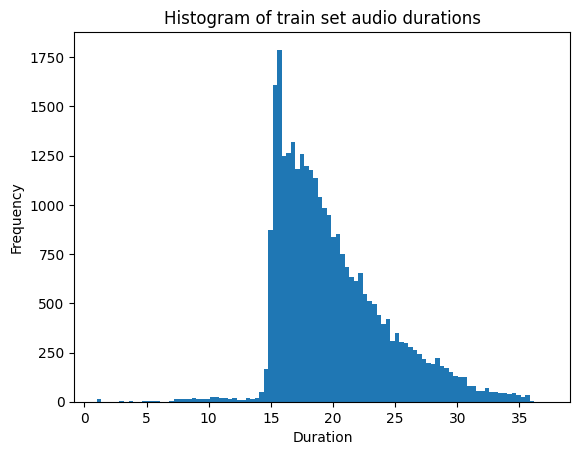

In [13]:
# Look at a histogram of 'duration'
plt.hist(waxal_train['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of train set audio durations')
plt.show()

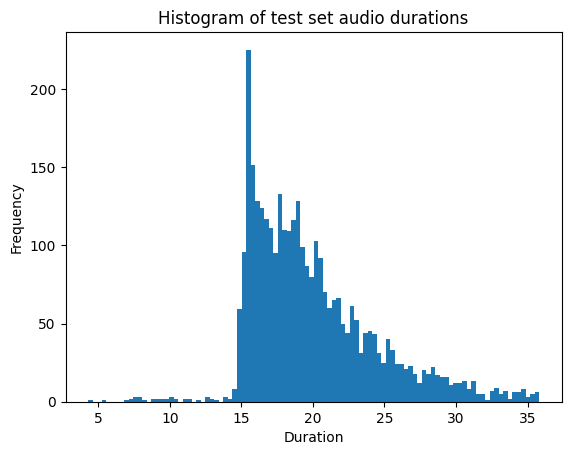

In [14]:
plt.hist(waxal_test['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of test set audio durations')
plt.show()

In [15]:
# Calculate total duration in hours
total_duration_train = sum(waxal_train['duration']) / 3600
total_duration_test = sum(waxal_test['duration']) / 3600

print(f"Total duration in hours for train set: {total_duration_train:.2f} hours")
print(f"Total duration in hours for test set: {total_duration_test:.2f} hours")

Total duration in hours for train set: 165.44 hours
Total duration in hours for test set: 18.55 hours


In [16]:
# Filter out long samples
MAX_DURATION = 30
waxal_train = waxal_train.filter(lambda x: x['duration'] < MAX_DURATION)
waxal_test = waxal_test.filter(lambda x: x['duration'] < MAX_DURATION)

Filter:   0%|          | 0/29867 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3347 [00:00<?, ? examples/s]

## ASRAfricaDataEfficiencyBenchmark

In [17]:
sna_bench_train = load_dataset("asr-africa/ASRAfricaDataEfficiencyBenchmark", "Shona", split="train")
sna_bench_test = load_dataset("asr-africa/ASRAfricaDataEfficiencyBenchmark", "Shona", split="test")

In [18]:
sna_bench_train

Dataset({
    features: ['creator', 'project_name', 'speaker_id', 'audio', 'image_path', 'transcription', 'locale', 'gender', 'age', 'year', 'duration', 'transcription_length'],
    num_rows: 175
})

In [19]:
sna_bench_test

Dataset({
    features: ['creator', 'project_name', 'speaker_id', 'audio', 'image_path', 'transcription', 'locale', 'gender', 'age', 'year', 'duration', 'transcription_length'],
    num_rows: 880
})

In [20]:
# Remove unnecessary columns
sna_bench_train = sna_bench_train.remove_columns(['creator', 'project_name', 'speaker_id', 'image_path', 'locale', 'gender', 'age', 'year', 'duration', 'transcription_length'])
sna_bench_test = sna_bench_test.remove_columns(['creator', 'project_name', 'speaker_id', 'image_path', 'locale', 'gender', 'age', 'year', 'duration', 'transcription_length'])

In [21]:
sna_bench_train

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 175
})

In [22]:
sna_bench_test

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 880
})

In [23]:
# Calculate duration
sna_bench_train = sna_bench_train.map(calculate_duration)
sna_bench_test = sna_bench_test.map(calculate_duration)

Map:   0%|          | 0/175 [00:00<?, ? examples/s]

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

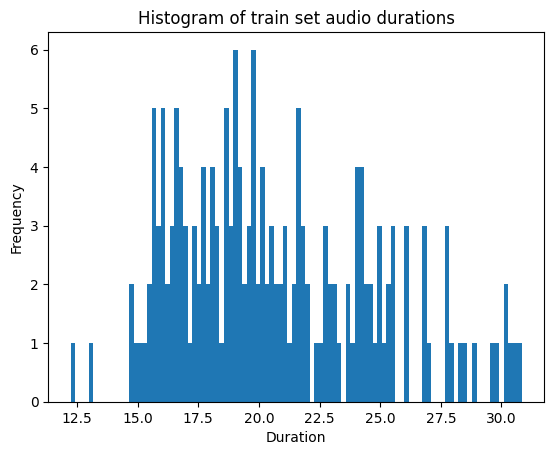

In [24]:
# Look at a histogram of 'duration'
plt.hist(sna_bench_train['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of train set audio durations')
plt.show()

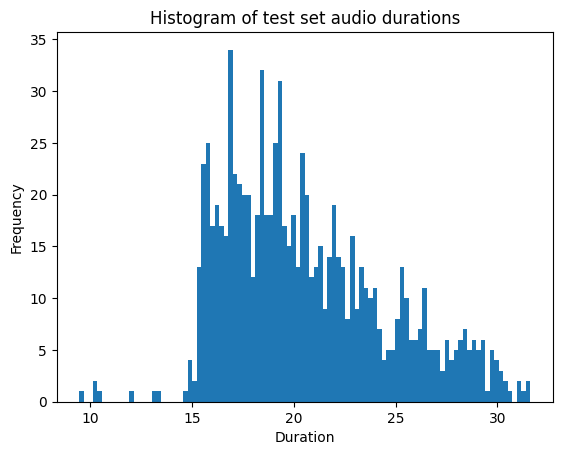

In [25]:
plt.hist(sna_bench_test['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of test set audio durations')
plt.show()

In [26]:
# Calculate total duration in hours
total_duration_train = sum(sna_bench_train['duration']) / 3600
total_duration_test = sum(sna_bench_test['duration']) / 3600

print(f"Total duration in hours for train set: {total_duration_train:.2f} hours")
print(f"Total duration in hours for test set: {total_duration_test:.2f} hours")

Total duration in hours for train set: 1.01 hours
Total duration in hours for test set: 5.04 hours


In [27]:
# Filter out long samples
sna_bench_train = sna_bench_train.filter(lambda x: x['duration'] < MAX_DURATION)
sna_bench_test = sna_bench_test.filter(lambda x: x['duration'] < MAX_DURATION)

Filter:   0%|          | 0/175 [00:00<?, ? examples/s]

Filter:   0%|          | 0/880 [00:00<?, ? examples/s]

In [28]:
sna_bench_train

Dataset({
    features: ['audio', 'transcription', 'duration'],
    num_rows: 170
})

In [29]:
sna_bench_test

Dataset({
    features: ['audio', 'transcription', 'duration'],
    num_rows: 868
})

## FLEURS

In [30]:
lin_fleurs_train = load_dataset("google/fleurs", "ln_cd", split="train+validation")
lin_fleurs_test = load_dataset("google/fleurs", "ln_cd", split="test")

In [31]:
lin_fleurs_train

Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 3559
})

In [32]:
lin_fleurs_test

Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 478
})

In [33]:
sna_fleurs_train = load_dataset("google/fleurs", "sn_zw", split="train+validation")
sna_fleurs_test = load_dataset("google/fleurs", "sn_zw", split="test")

In [34]:
# Concatenate
fleurs_train = concatenate_datasets([lin_fleurs_train, sna_fleurs_train])
fleurs_test = concatenate_datasets([lin_fleurs_test, sna_fleurs_test])

In [35]:
fleurs_train

Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 6415
})

In [36]:
fleurs_test

Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 1403
})

In [37]:
# Remove unnecessary columns
fleurs_train = fleurs_train.remove_columns(['id', 'num_samples', 'path', 'transcription', 'gender', 'lang_id', 'language', 'lang_group_id'])
fleurs_test = fleurs_test.remove_columns(['id', 'num_samples', 'path', 'transcription', 'gender', 'lang_id', 'language', 'lang_group_id'])

In [38]:
# Rename 'raw_transcription' to 'transcription'
fleurs_train = fleurs_train.rename_column('raw_transcription', 'transcription')
fleurs_test = fleurs_test.rename_column('raw_transcription', 'transcription')

In [39]:
fleurs_train

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 6415
})

In [40]:
fleurs_test

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 1403
})

In [41]:
# Calculate duration
fleurs_train = fleurs_train.map(calculate_duration)
fleurs_test = fleurs_test.map(calculate_duration)

Map:   0%|          | 0/6415 [00:00<?, ? examples/s]

Map:   0%|          | 0/1403 [00:00<?, ? examples/s]

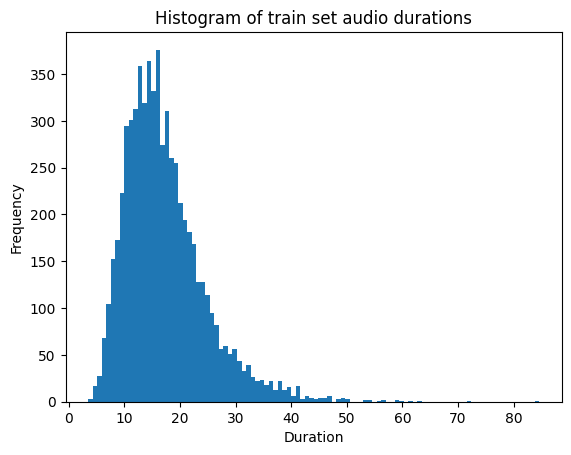

In [42]:
# Look at a histogram of 'duration'
plt.hist(fleurs_train['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of train set audio durations')
plt.show()

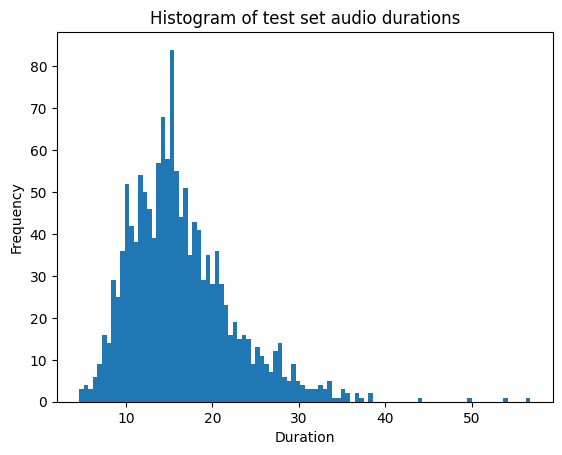

In [43]:
plt.hist(fleurs_test['duration'], bins=100)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Histogram of test set audio durations')
plt.show()

In [44]:
# Calculate total duration in hours
total_duration_train = sum(fleurs_train['duration']) / 3600
total_duration_test = sum(fleurs_test['duration']) / 3600

print(f"Total duration in hours for train set: {total_duration_train:.2f} hours")
print(f"Total duration in hours for test set: {total_duration_test:.2f} hours")

Total duration in hours for train set: 30.83 hours
Total duration in hours for test set: 6.40 hours


In [45]:
# Filter out long samples
fleurs_train = fleurs_train.filter(lambda x: x['duration'] < MAX_DURATION)
fleurs_test = fleurs_test.filter(lambda x: x['duration'] < MAX_DURATION)

Filter:   0%|          | 0/6415 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1403 [00:00<?, ? examples/s]

In [46]:
fleurs_train

Dataset({
    features: ['audio', 'transcription', 'duration'],
    num_rows: 6031
})

In [47]:
fleurs_test

Dataset({
    features: ['audio', 'transcription', 'duration'],
    num_rows: 1360
})

# Concatenate and save

In [48]:
# Concatenate all datasets
train = concatenate_datasets([waxal_train, sna_bench_train, fleurs_train])
test = concatenate_datasets([waxal_test, sna_bench_test, fleurs_test])

# Remove 'duration' column
train = train.remove_columns(['duration'])
test = test.remove_columns(['duration'])

# Shuffle
train = train.shuffle(seed=1337)

# Resample to 16khz
train = train.cast_column("audio", Audio(sampling_rate=16000))
test = test.cast_column("audio", Audio(sampling_rate=16000))

In [49]:
train

Dataset({
    features: ['transcription', 'audio'],
    num_rows: 35099
})

In [50]:
test

Dataset({
    features: ['transcription', 'audio'],
    num_rows: 5446
})

In [51]:
dataset_lin_sna = DatasetDict({
    'train': train,
    'test': test
})

# Save to disk
dataset_lin_sna.save_to_disk("./dataset_lin_sna")

Saving the dataset (0/31 shards):   0%|          | 0/35099 [00:00<?, ? examples/s]

Saving the dataset (0/8 shards):   0%|          | 0/5446 [00:00<?, ? examples/s]